# Spacecraft AOSC Jitter

In this notebook we are making a direct comparison between the simulated AOSC data by Prime and the red noise model PlatoSim currently use for the jitter and Thermo-Elastic Distortion (TED) drift.  

In [1]:
%matplotlib inline

import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
from scipy.interpolate import make_interp_spline
from scipy.ndimage import median_filter
from scipy import constants as c

from platosim.noise import *
from platosim.plot import *

# Handle warnings

import warnings
warnings.filterwarnings('ignore')

# Change matplotlib defautls

plt.rc('xtick', labelsize=13) 
plt.rc('ytick', labelsize=13) 
plt.rcParams.update({'font.size': 13})

---
## AOSC Jitter
---

We first have a look at the jitter which is the AOSC on a short time scale. In the following we have simulated a time series using the exact jitter time scale of 0.125 second and the same Root-Mean-Square (RMS) values of yaw, pitch, and roll from estimated for the Prime jitter time series. Since the Prime time series is $0.125 s \times 79,2001 = 99,000 \times 25 s = 27.5 h$, the PlatoSim simulation convers the same time duration. 

### Load jitter data

In [2]:
# SELECT YOUR FILE LOCATION!!!

inputDir = os.getcwd() + '/../../models/aocs_prime_2021-01'

# Load Prime jitter file

filename_jitter_prime = inputDir + '/01_PLATO_PDR_FPM_02_longrun_APE.csv'
f_jitter_prime = np.loadtxt(filename_jitter_prime, delimiter=';')

time_jitter_prime = f_jitter_prime[:,0] - f_jitter_prime[:,0][0]  # [s] Measure from 1000s needs to be subtracted
xJitter_prime     = f_jitter_prime[:,1] * rad2arcsec    # [arcsec]
yJitter_prime     = f_jitter_prime[:,2] * rad2arcsec    # [arcsec]
zJitter_prime     = f_jitter_prime[:,3] * rad2arcsec    # [arcsec]
data_jitter_prime = [xJitter_prime, yJitter_prime, zJitter_prime]
samp_jitter = time_jitter_prime[1] - time_jitter_prime[0]

# Load PlatoSim jitter file

filename_jitter_platosim = os.getcwd() + '/jitter_tscale-0.125s_tdur-28d.hdf5'
f_jitter_platosim = h5py.File(filename_jitter_platosim, 'r')

time_jitter_platosim = np.array(f_jitter_platosim['ACS/Time'])  # [s]
xJitter_platosim     = np.array(f_jitter_platosim['ACS/Yaw'])   - np.median(np.array(f_jitter_platosim['ACS/Yaw']))  # [arcsec]
yJitter_platosim     = np.array(f_jitter_platosim['ACS/Pitch']) - np.median(np.array(f_jitter_platosim['ACS/Yaw']))  # [arcsec]
zJitter_platosim     = np.array(f_jitter_platosim['ACS/Roll'])  - np.median(np.array(f_jitter_platosim['ACS/Yaw']))  # [arcsec]
data_jitter_platosim = [xJitter_platosim, yJitter_platosim, zJitter_platosim]

# Print information for the two data sets

print('Data information: Prime vs. PlatoSim')
print('Data points   : {}, {}'.format(len(time_jitter_prime), len(time_jitter_platosim)))
print('Time duration : {:.2f}, {:.2f} h'.format(time_jitter_prime[-1]/3600., time_jitter_platosim[-1]/3600.))
print('Time sampling : {}, {} s'.format(np.diff(time_jitter_prime)[0], np.diff(time_jitter_platosim)[0]))
print('')

Data information: Prime vs. PlatoSim
Data points   : 792001, 665280
Time duration : 27.50, 27.50 h
Time sampling : 0.125, 0.125 s



### Compare jitter time series

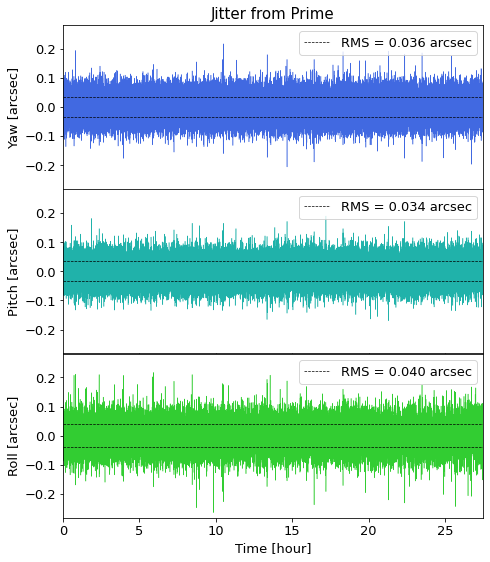

In [3]:
# Plot Prime time series of yaw, pitch, and roll

fig = plt.figure(figsize=(7,8))
ax0 = plotYawPitchRollTimeSeries(fig, time_jitter_prime/3600., data_jitter_prime, units=['hour', 'arcsec'], 
                                  title='Jitter from Prime')
plt.show()

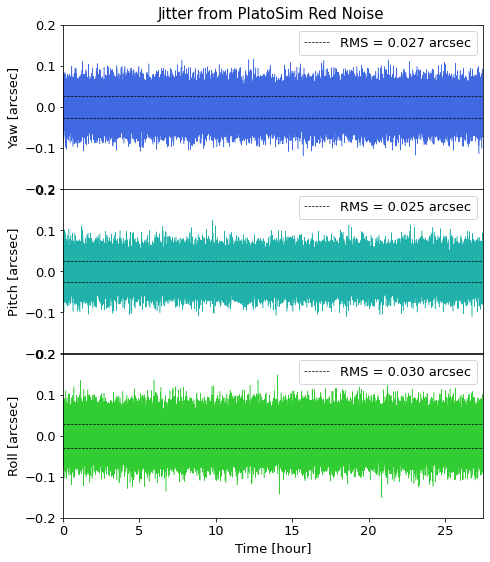

In [4]:
# PLot PLATOSim jitter time series

fig = plt.figure(figsize=(7,8))
ax1 = plotYawPitchRollTimeSeries(fig, time_jitter_platosim/3600., data_jitter_platosim, units=['hour', 'arcsec'], 
                                  title='Jitter from PlatoSim Red Noise ', ylim=0.2)
plt.show()

### Compare PSD plots

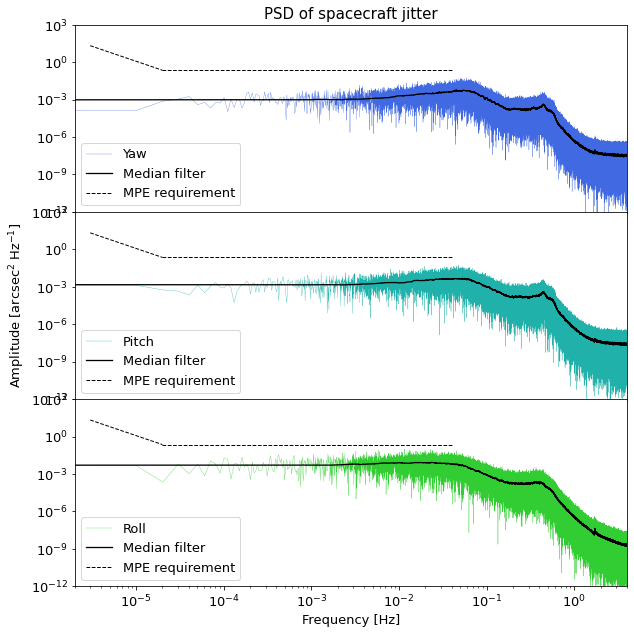

In [5]:
# Plot Prime PSD of yaw, pitch, and roll - We use mega-seconds to convert to micro-Hz

fig = plt.figure(figsize=(9,9))
plotYawPitchRollPSD(fig, time_jitter_prime, data_jitter_prime, title='PSD of spacecraft jitter', 
                    carbox=480, scale=1, misreq=True, xmin=2e-6, ylim=[1e-12, 1e3])
plt.show()
#fig.savefig('/home/nicholas/Nextcloud/Platoman/DocumentRepository/
#PLATO-KUL-PL-TN-0017_ICUimagetteCompressionTest/plotJitterPSD.png', dpi=300)

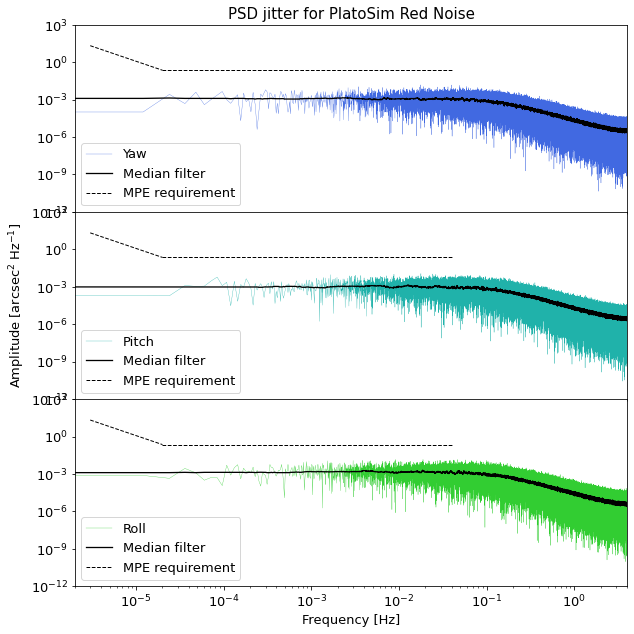

In [6]:
# Plot PlatoSim PSD of yaw, pitch, and roll for Red Noise jitter

fig = plt.figure(figsize=(9,9))
plotYawPitchRollPSD(fig, time_jitter_platosim, data_jitter_platosim, title='PSD jitter for PlatoSim Red Noise', 
                    scale=1, xmin=2e-6, ylim=[1e-12, 1e3], misreq=True)
plt.show()

### Fit Nosie model of jitter

In [7]:
# Noise model

def rednoise(freq, tau, sigma):
    sigma**2 * tau / (1 + (2*np.pi*freq*tau)**2 )

def find_nearest(array, value):
    array = np.asarray(array)
    dex = (np.abs(array - value)).argmin()
    return dex, array[dex]

def noiseModel(freq, timescale, varscale, noisepower):

    """
    PURPOSE: compute the mean power spectral density (PSD) corresponding to the red noise
             time series that is generated by redNoise().

    INPUT: freq:       frequency points of the PSD  [microHz | mHz | Hz]
           timescale:  see the function rednoise()
           varscale:   see the function rednoise()

    OUTPUT: psd:  power spectral density   [ppm^2/microHz | ppm^2/microHz | ppm^2/microHz]
    """

    psd = np.zeros_like(freq)

    for n in range(len(timescale)):
        sigma = varscale[n]
        tau = timescale[n]
        psd += sigma * sigma * tau / (1.0 + (2.0*np.pi*freq*tau)**noisepower)
    
    return psd

# Prepare fit

#from lmfit import Model
#gmodel = Model(rednoise)
#print(f'parameter names: {gmodel.param_names}')
#print(f'independent variables: {gmodel.independent_vars}')

In [8]:
# Create white noise model for jitter

timescale = [25e-6]     # [Ms]
varscale  = [0.05]  # [arcsec] 

time_white = np.arange(0, 88.*86400,25) * 1e-6  # [Ms]
noise_white = modelRedNoiseTimeSeries(time_white, np.array([timescale[0]]), np.array([varscale[0]]))  
freq_white, PSD_white = powerDensityFFT(noise_white, np.diff(time_white)[0]) 

fig = plt.figure(figsize=(8,4))
plotPSD(fig, freq_white, PSD_white, carbox=False, linewidth=2, #xlim=[1e2, freq_white[-1]], ylim=[1e-18, 1e-6],
        colors=['tomato'], units=['$\mu$Hz', 'arcsec'], title='PSD Jitter white noise')
plt.show()

Simulating 1 component(s)
Kicktimestep = 2.5e-07
Warming up...


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(np.random.normal) found for signature:
 
 >>> <unknown function>(array(float64, 1d, C), array(float64, 1d, C))
 
There are 2 candidate implementations:
[1m   - Of which 2 did not match due to:
   Overload in function 'Numpy_normal.generic': File: numba/core/typing/randomdecl.py: Line 215.
     With argument(s): '(array(float64, 1d, C), array(float64, 1d, C))':[0m
[1m    No match for registered cases:
     * (float64, float64) -> float64
     * (float64,) -> float64
     * () -> float64[0m
[0m
[0m[1mDuring: resolving callee type: Function(np.random.normal)[0m
[0m[1mDuring: typing of call at /home/nicholas/software/python/PlatoSim3/python/platosim/noise.py (77)
[0m
[1m
File "../../../PlatoSim3/python/platosim/noise.py", line 77:[0m
[1mdef simRedNoise(time, kicktimestep, Ntime, noise, timescale, mu, sigma, varscale, signal):
    <source elided>
        w

In [ ]:
# Cut of first jitter knee of prime data

freq_prime, PSD_prime = powerDensityFFT(data_jitter_prime[0], samp_jitter/1e6)
PSD_med = median_filter(PSD_prime, 100)

dex_knee1, _ = find_nearest(freq_prime, 2e5)
freq_knee1 = freq_prime[:dex_knee1]
PSD_knee1  = PSD_prime[:dex_knee1]

dex_knee2, _ = find_nearest(freq_prime, 2e6)
freq_knee2 = freq_prime[dex_knee1:dex_knee2]
PSD_knee2  = PSD_prime[dex_knee1:dex_knee2]

# Fit a noise model to each component

timescale = [1/4.5e5, 1/3e6, 1]  # [Ms]
varscale  = [0.05,    0.025,  0.0008]   # [arcsec] 

PSD_red1  = noiseModel(freq_prime, np.array([timescale[0]]), np.array([varscale[0]]), 6)  
PSD_red2  = noiseModel(freq_prime, np.array([timescale[1]]), np.array([varscale[1]]), 7)
PSD_white = noiseModel(freq_prime, np.array([timescale[2]]), np.array([varscale[2]]), 1)

PSD_model = PSD_red1 + PSD_red2 + PSD_white

# Combine data and make plot

freq = [freq_knee1, freq_knee2, freq_prime, freq_prime]
PSD  = [PSD_knee1, PSD_knee2, PSD_med, PSD_model]

fig = plt.figure(figsize=(8,4))
plotPSD(fig, freq, PSD, carbox=False, linewidth=2, xlim=[1e2, freq_prime[-1]], ylim=[1e-18, 1e-6],
        colors=['tomato', 'darkorange', 'lightblue', 'k'], units=['$\mu$Hz', 'arcsec'], title='PSD Jitter Red Noise')
plt.show()

### Residual jitter

We can now check the residual plots of the two time series in the frequency domain which both are computed with a sampling of 0.125 seconds.

In [ ]:
# Find PSD residuals of yaw, pitch, and roll

n = np.min([len(time_jitter_prime), len(time_jitter_platosim)])

xRes = data_jitter_prime[0][:n] - data_jitter_platosim[0][:n]
yRes = data_jitter_prime[1][:n] - data_jitter_platosim[1][:n]
yRes = data_jitter_prime[2][:n] - data_jitter_platosim[2][:n]
data = [xRes, yRes, yRes]

# Plot residual plot

#fig = plt.figure(figsize=(8,9))
#plotYawPitchRollPSD(fig, time_jitter_prime, data, title='PSD residuals', xmin=1e2, misreq=True)
#plt.show()

## AOCS Drift
---

Time to look at the drift motion of cameras, which is composed of of Thermo-Elastic Distortion (TED) relevant for each camera and a Differential Kinematic Abbreviation (DKA) which varies across the FOV as a function of the velocity vector of the spacescraft's motion. In theory the DKA can be as high as 20" = 1.3 pixel in 3 months. However, this is the level of DKA one would have in principle with a field of view of 90° (in radius). Although large, the PLATO FOV is no larger than ~28° (in radius) such that the DKA is not going to exceed ~0.8 pixel in 3 months.

Furthermore, in the mission requirements the TED induced by the platform is not allowed to exceed 0.4 pixel. In practice according to Prime this is not going to exceed 2/100 pixel in 3 months. Accordingly, the DKA should be the dominant source of drift. Since the latter is fully predictable this can simplify a lot the current mask update strategy (PLATO-LESIA-PDC-DD-0022, i1.0). Indeed, the current one assumes than the drift is not predictable and thus has to be monitored continuously during the quarter for all stars (and all cameras).

### Load Prime TED (sampling = 1 h,  duration = 90 d)

In [ ]:
# Load file

filename = inputDir + '/04_rev349_ARC3_EOL_90d_3600.csv'
data = np.loadtxt(filename, delimiter=';')

# Time points and sampling

time_ted = data[:,0]                  # [s]
samp_ted = time_ted[1] - time_ted[0]  # [s]

# Prepare for plotting

color = cm.rainbow(np.linspace(0,1,49))
cams = ['CAM 1.1', 'CAM 1.2', 'CAM 1.3', 'CAM 1.4', 'CAM 1.5', 'CAM 1.6', 
        'CAM 2.1', 'CAM 2.2', 'CAM 2.3', 'CAM 2.4', 'CAM 2.5', 'CAM 2.6',
        'CAM 3.1', 'CAM 3.2', 'CAM 3.3', 'CAM 3.4', 'CAM 3.5', 'CAM 3.6',
        'CAM 4.1', 'CAM 4.2', 'CAM 4.3', 'CAM 4.4', 'CAM 4.5', 'CAM 4.6',]

### Plot TED time series (cartesian + rotational)

In [ ]:
# Prepare a mean calculation

ted_dir = np.zeros((24,len(data)))
ted_rot = np.zeros((24,len(data)))

fig, ax = plt.subplots(2, 1, figsize=(11,11))

for i,c in zip(range(data.shape[1]-1), color):
    
    # Plot even number i.e. directional in file
    if i % 2 == 0:
        ax[0].plot(time_ted/86400., data[:,i+1], '-', c=c, label='{}'.format(cams[int(i/2)]))
        ted_dir[int(i/2),:] = data[:,i+1]
        
    # Plot odd number i.e. rotational in file
    if i % 2 != 0:
        ax[1].plot(time_ted/86400., data[:,i+1], '-', c=c, label='{}'.format(cams[int(i/2)]))
        ted_rot[int(i/2),:] = data[:,i+1]
        
# Find mean values
ted_dir_mean = np.mean(ted_dir, axis=0)
ted_rot_mean = np.mean(ted_rot, axis=0)          

# Plot mean values
ax[0].plot(time_ted/86400., ted_dir_mean, 'k-', lw=5, label='Mean')  
ax[1].plot(time_ted/86400., ted_rot_mean, 'k-', lw=5, label='Mean')  

# Plot settings
ax[0].set_title('Cartesian TED')   
ax[1].set_title('Rotational TED')   
ax[1].set_xlabel('Time [days]')
ax[0].set_ylabel('Amplitude [arcsec]')
ax[1].set_ylabel('Amplitude [arcsec]')
ax[0].legend(bbox_to_anchor=(1.01, 0.8))
plt.show()

# Save figure
#fig.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimeTED.png', bbox_inches='tight', dpi=300)

In [ ]:

a = np.array([time_ted, ted_dir[0], ted_dir[0], ted_rot[0]])
print(a.T)
np.savetxt('/home/nicholas/software/python/platonium/models/drift_Ncam1.1_Q1.txt', a.T)

### Plot TED PSD

In [ ]:
# First subtract the mean

_, PSD_dir_mean = powerDensityFFT(ted_dir_mean-np.mean(ted_dir_mean)+1, samp_ted)
_, PSD_rot_mean = powerDensityFFT(ted_rot_mean-np.mean(ted_rot_mean)+1, samp_ted)

# Prepare a mean calculation

import math

PSD_dir  = []
PSD_rot  = []
freq_ted = []

for i in range(24):
    
    ted_dir_i = ted_dir[i] - np.mean(ted_dir[i])
    ted_rot_i = ted_rot[i] - np.mean(ted_rot[i])

    freq_ted_i, PSD_dir_i = powerDensityFFT(ted_dir_i, samp_ted)
    _,          PSD_rot_i = powerDensityFFT(ted_rot_i, samp_ted)
    
    freq_ted.append(freq_ted_i)
    PSD_dir.append(PSD_dir_i)
    PSD_rot.append(PSD_rot_i)
   
# Plot Directional TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, PSD_dir, carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

# PLot Rotational TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, PSD_rot, carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

# Plot Mean TED
fig = plt.figure(figsize=(10,5))
plotPSD(fig, freq_ted, [PSD_dir_mean, PSD_rot_mean], carbox=False, linewidth=2, xlim=[1e-7, np.max(freq_ted)], ylim=[1e-6, 1e4], 
        units=['Hz', 'arcsec'], title='PSD TED directional', misreq=True)
plt.show()

In [ ]:
# Interpolate (piecewise cubic) into higher resolution grid

grid_no  = int(time_ted[-1]/25.)
time_int = np.linspace(time_ted[0], time_ted[-1], grid_no)
samp_int = 25.

# All 24 cams

ted_int_dir = np.zeros((24, grid_no))
ted_int_rot = np.zeros((24, grid_no))

for i in range(24):
    grid_dir = make_interp_spline(time_ted, ted_dir[i], k=3)
    grid_rot = make_interp_spline(time_ted, ted_rot[i], k=3)
    ted_int_dir[i,:] = grid_dir(time_int)
    ted_int_rot[i,:] = grid_rot(time_int)

# Mean values

ted_int_dir_mean = np.mean(ted_int_dir, axis=0)
ted_int_rot_mean = np.mean(ted_int_rot, axis=0)
    
# Find freq and PSD

freq_ted_int, PSD_int_dir_mean = powerDensityFFT(ted_int_dir_mean, samp_int)

freq_jitter, PSD_xJitter = powerDensityFFT(data_jitter_prime[0], samp_jitter)
_,           PSD_yJitter = powerDensityFFT(data_jitter_prime[1], samp_jitter)
_,           PSD_zJitter = powerDensityFFT(data_jitter_prime[2], samp_jitter)

freq = [freq_ted[20], freq_jitter]
PSDx  = [PSD_dir[20], PSD_xJitter]
PSDy  = [PSD_dir[20], PSD_yJitter]
PSDz  = [PSD_rot[20], PSD_zJitter]

# Plot new interpolation for PSD

fig0 = plt.figure(figsize=(9,3.5))
plotPSD(fig0, freq, PSDx, carbox=100, linewidth=1, colors=['c', 'lightgreen'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Dir', 'AOCS Yaw', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

fig1 = plt.figure(figsize=(9,3.5))
plotPSD(fig1, freq, PSDy, carbox=100, linewidth=1, colors=['c', 'limegreen'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Dir', 'AOCS Pitch', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

fig2 = plt.figure(figsize=(9,3.5))
plotPSD(fig2, freq, PSDz, carbox=100, linewidth=1, colors=['b', 'g'], units=['Hz', 'arcsec'], 
        xlim=[1e-6, np.max(freq_jitter)], ylim=[1e-12, 1e3], misreq=True,
        labels=['TED Rot', 'AOCS Roll', 'Jitter Yaw'], title='PSD TED directional')
plt.show()

# Save figure
#fig0.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDYaw.png', bbox_inches='tight', dpi=300)
#fig1.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDPitch.png', bbox_inches='tight', dpi=300)
#fig2.savefig('/home/nicholas/Nextcloud/presentations/presentation_PW12/plotPrimePSDRoll.png', bbox_inches='tight', dpi=300)

## Prime AOCS and TED time series with sampling = 12.5 s and duration = 27 d

In [ ]:
filename = '/home/nicholas/software/python/platonium/models/aocs_prime_2021-01/03_PLATO_PDR_AOCSandTED.csv'
data = np.loadtxt(filename, delimiter=';')

time = data[:,0]  # [s]
x    = data[:,1]  # [arcsec]
y    = data[:,2]  # [arcsec]
z    = data[:,3]  # [arcsec]
data = [x, y, z]

In [ ]:
# Plot time series of yaw, pitch, and roll

fig = plt.figure(figsize=(8,9))
axes = plotYawPitchRollTimeSeries(fig, time/3600., data, units=['hours', 'arcsec'], title='Jitter+TED from Prime')
plt.show()

In [ ]:
# Plot PSD of yaw, pitch, and roll for Red Noise jitter

fig = plt.figure(figsize=(8,9))
plotYawPitchRollPSD(fig, time, data, title='PSD jitter + TED from Prime', xmin=1e2, misreq=True)
plt.show()